In [1]:
import numpy as np 
import os 
import PIL
import PIL.Image
import tensorflow as tf 
import tensorflow_datasets as tfds 

In [2]:
print(tf.__version__)


2.20.0


In [3]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(archive).with_suffix('')



In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)


3670


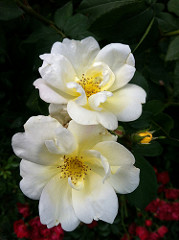

In [5]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))


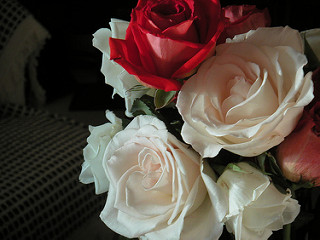

In [6]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[1]))


In [7]:
batch_size = 32 
img_height = 180 
img_width = 180

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [10]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


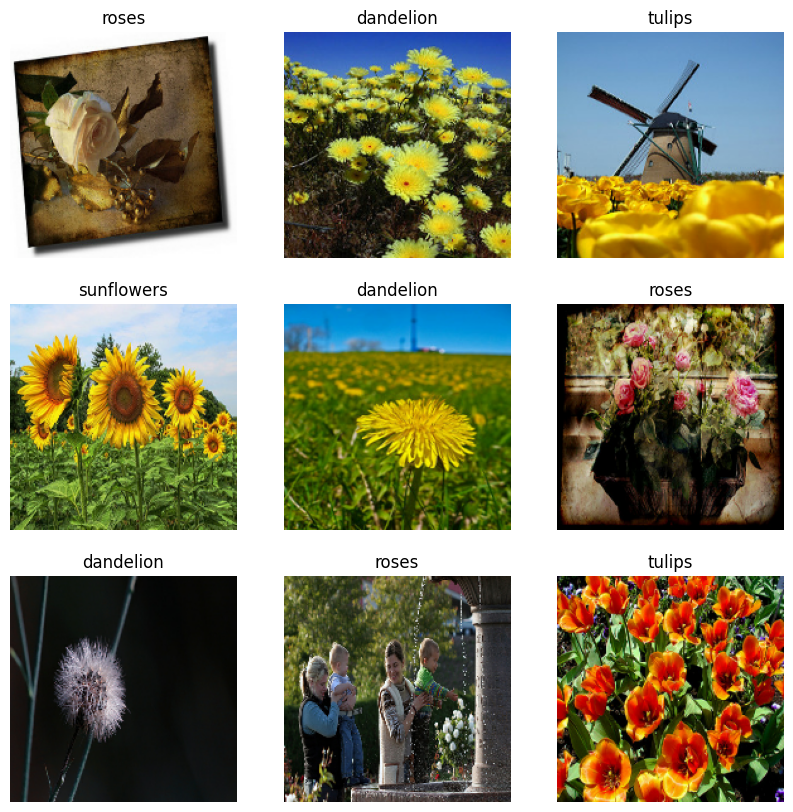

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


In [12]:
for image_batch, labels_batch in train_ds: 
    print(image_batch.shape) 
    print(labels_batch.shape)
    break

(32, 180, 180, 3)
(32,)


In [13]:
normalization_layer = tf.keras.layers.Rescaling(1./ 255)

In [14]:
normalized_ds  = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]

print(np.min(first_image), np.max(first_image))

0.0 0.96902645


In [15]:
AUTOTUNE = tf.data.AUTOTUNE 

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [16]:
num_classes = 5 

model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255), 
        tf.keras.layers.Conv2D(32, 3, activation='relu'), 
        tf.keras.layers.MaxPooling2D(), 
        tf.keras.layers.Conv2D(32, 3, activation='relu'), 
        tf.keras.layers.MaxPooling2D(), 
        tf.keras.layers.Conv2D(32, 3, activation='relu'), 
        tf.keras.layers.MaxPooling2D(), 
        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dense(128, activation='relu'), 
        tf.keras.layers.Dense(num_classes)

])

In [17]:
model.compile(
    optimizer = 'adam', 
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), 
    metrics = ['accuracy']
)

In [18]:
model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=3
)


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.4489 - loss: 1.2788 - val_accuracy: 0.5708 - val_loss: 1.0975
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.6090 - loss: 0.9903 - val_accuracy: 0.5777 - val_loss: 1.0618
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.6662 - loss: 0.8771 - val_accuracy: 0.6131 - val_loss: 0.9731


In [20]:
list_ds = tf.data.Dataset.list_files(str(data_dir/'*/*'), shuffle= False)
list_ds = list_ds.shuffle(image_count, reshuffle_each_iteration=False)

In [21]:
for f in list_ds.take(5): 
    print(f.numpy())

b'C:\\Users\\user\\.keras\\datasets\\flower_photos\\sunflowers\\2759796022_55bd47bfa2_n.jpg'
b'C:\\Users\\user\\.keras\\datasets\\flower_photos\\dandelion\\2596413098_7ef69b7e1d_m.jpg'
b'C:\\Users\\user\\.keras\\datasets\\flower_photos\\sunflowers\\6198569425_e953b9e6cc_m.jpg'
b'C:\\Users\\user\\.keras\\datasets\\flower_photos\\sunflowers\\2950505226_529e013bf7_m.jpg'
b'C:\\Users\\user\\.keras\\datasets\\flower_photos\\tulips\\14074147406_7ab87aec79_n.jpg'


In [22]:
class_names = np.array(sorted([item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt"]))
print(class_names)

['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


In [23]:
val_size = int(image_count * 0.2) 
train_ds = list_ds.skip(val_size) 
val_ds = list_ds.take(val_size)

In [24]:
print(tf.data.experimental.cardinality(train_ds).numpy())
print(tf.data.experimental.cardinality(val_ds).numpy())

2936
734


In [25]:
def get_label(file_path): 
    #convert the path to a list of path components 
    parts = tf.strings.split(file_path, os.path.sep) 
    # the second to last i sthe class-directory 
    one_hot = parts[-2] == class_names 
    # Integer encode the label 
    return tf.argmax(one_hot)

In [27]:
def decode_img(img): 
    # convert the compressed string to a 3d uint8 tensor 
    img = tf.io.decode_jpeg(img, channels=3)
    #resize the image to desired size 
    return tf.image.resize(img, [img_height, img_width])

In [28]:
def process_path(file_path): 
    label = get_label(file_path)
    # Load the raw data from the file as a string 
    img = tf.io.read_file(file_path) 
    img = decode_img(img)
    return img, label

In [29]:
# set 'num_parallel_calls' so multiple images are loaded/processed in parallel 
train_ds = train_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(process_path, num_parallel_calls=AUTOTUNE)

In [30]:
for image, label in train_ds.take(1): 
    print("Image shape: ", image.numpy().shape)
    print("label: ", label.numpy())

Image shape:  (180, 180, 3)
label:  2


In [31]:
def configure_for_performance(ds): 
    ds = ds.cache() 
    ds = ds.shuffle(buffer_size = 1000) 
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds 

train_ds = configure_for_performance(train_ds) 
val_ds = configure_for_performance(val_ds)

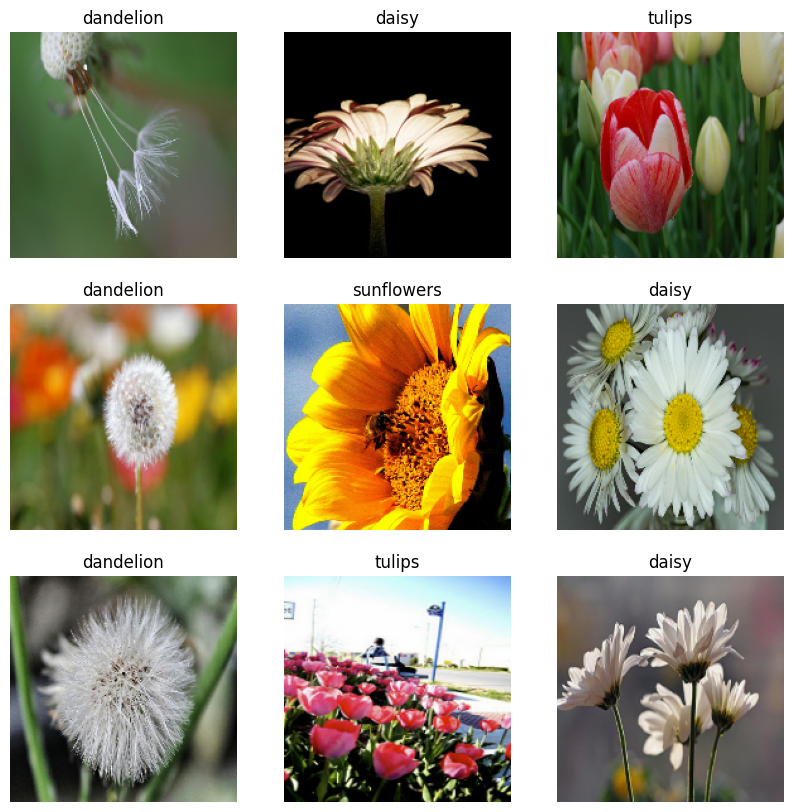

In [32]:
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  label = label_batch[i]
  plt.title(class_names[label])
  plt.axis("off")


In [33]:
model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=3
)


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.7037 - loss: 0.7715 - val_accuracy: 0.7384 - val_loss: 0.7213
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.7738 - loss: 0.6108 - val_accuracy: 0.6907 - val_loss: 0.8748
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8256 - loss: 0.4646 - val_accuracy: 0.7384 - val_loss: 0.7510


In [34]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers', 
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True, 
    as_supervised=True
)

e:\programs\py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 100%|██████████| 1/1 [01:25<00:00, 85.27s/ url]


Dataset tf_flowers downloaded and prepared to C:\Users\user\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.


In [35]:
num_classes = metadata.features['label'].num_classes
print(num_classes)


5


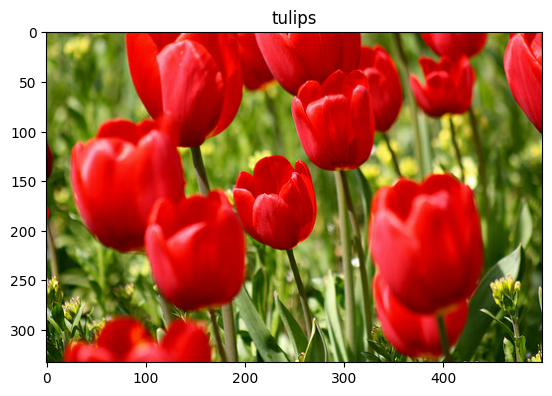

In [36]:
get_label_name = metadata.features['label'].int2str

image, label = next(iter(train_ds))
_ = plt.imshow(image)
_ = plt.title(get_label_name(label))


In [ ]:
train_ds = configure_for_performance(train_ds)
val_ds = configure_for_performance(val_ds)
test_ds = configure_for_performance(test_ds)
